<a href="https://colab.research.google.com/github/Sapar-hub/aie-group-2-sapar/blob/main/project/notebooks/exp02_synthetic_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Colab Setup

⚠️ **Запустить только один раз!** Клонирует репозиторий (sparse checkout) и устанавливает зависимости.

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    %cd /content
    !rm -rf aie-group-2-sapar
    !git init aie-group-2-sapar
    %cd aie-group-2-sapar
    !git sparse-checkout set project
    !git remote add origin https://github.com/Sapar-hub/aie-group-2-sapar.git
    !git pull origin main
    %cd project
    !pip install -q opencv-python-headless
    !nvidia-smi


/content
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/aie-group-2-sapar/.git/
/content/aie-group-2-sapar
remote: Enumerating objects: 1208, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 1208 (delta 39), reused 70 (delta 26), pack-reused 1114 (from 1)
Receiving objects: 100% (1208/1208), 554.59 MiB | 30.60 MiB/s, done.
Resolving deltas: 100% (389/389), done.
From https://github.com/Sapar-hub/aie-group-2-sapar
 * branch            main       ->

# Synthetic Data Generation

**Цель:** Генерация синтетических чертежей двумя способами:
1. **GOST генерация** — рисуем штамп по ГОСТ (185×55mm)
2. **Copy-paste** — копируем реальный штамп на другой чертёж

**Параметры:**
- Штамп: 185×55mm (FORM_3)
- DPI: 200
- Corner placement: random


In [2]:
import sys
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    sys.path.insert(0, 'src')
    DATA_DIR = Path('data')
else:
    sys.path.insert(0, '../src')
    DATA_DIR = Path('../data')

from data.loader import load_image_and_labels
from data.synthetic import (
    generate_synthetic_image,
    generate_synthetic_from_real,
    generate_synthetic_image_on_background,
    crop_stamp_from_image,
    resize_stamp_for_bg,
    place_by_orientation,
    GOST_FORMS,
)

IMAGE_DIR = DATA_DIR / 'images' / 'test'
LABEL_DIR = DATA_DIR / 'labels' / 'test'

print('OK')


OK


## Метод 1: GOST генерация

Генерируем штамп по ГОСТ (185×55mm) с сеткой и текстом.

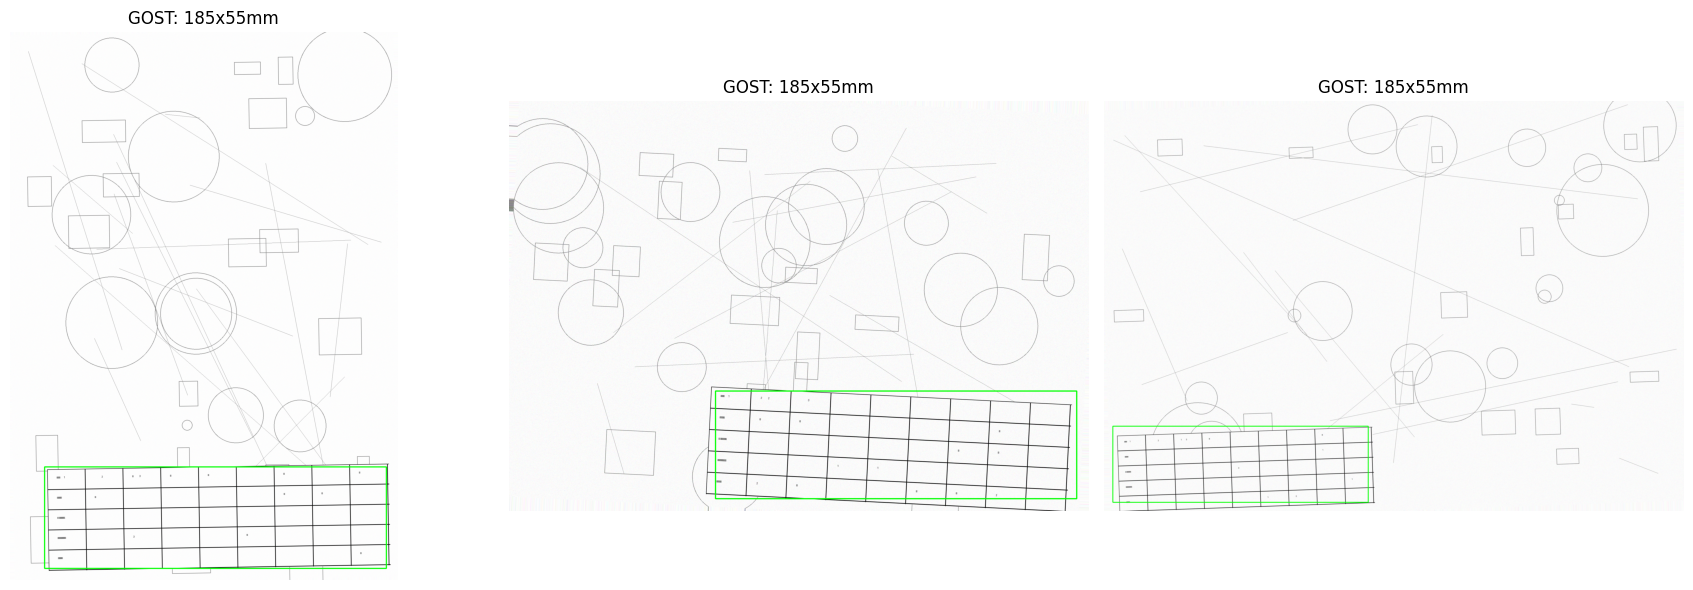

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    img, label, meta = generate_synthetic_image(dpi=200)
    x, y, w, h = meta['stamp_bbox']
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 3)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"GOST: {meta['form_width_mm']}x{meta['form_height_mm']}mm")
    ax.axis('off')

plt.tight_layout()
plt.show()


## Метод 2: Copy-paste штампов

Копируем реальные штампы из размеченных изображений на другие чертежи.

In [4]:
# Загружаем реальные изображения и вырезаем штампы
all_images = sorted(IMAGE_DIR.glob('*.png')) + sorted(IMAGE_DIR.glob('*.jpg'))
real_stamps = []

for img_path in all_images:
    img, lbls = load_image_and_labels(img_path, LABEL_DIR)
    if lbls.size > 0:
        stamp = crop_stamp_from_image(img, lbls, margin=0.05)
        if stamp.size > 0:
            real_stamps.append((img_path, img, stamp))

print(f'Загружено штампов: {len(real_stamps)}')
if real_stamps:
    print(f'Пример штампа: {real_stamps[0][2].shape}')


Загружено штампов: 49
Пример штампа: (370, 1492, 3)


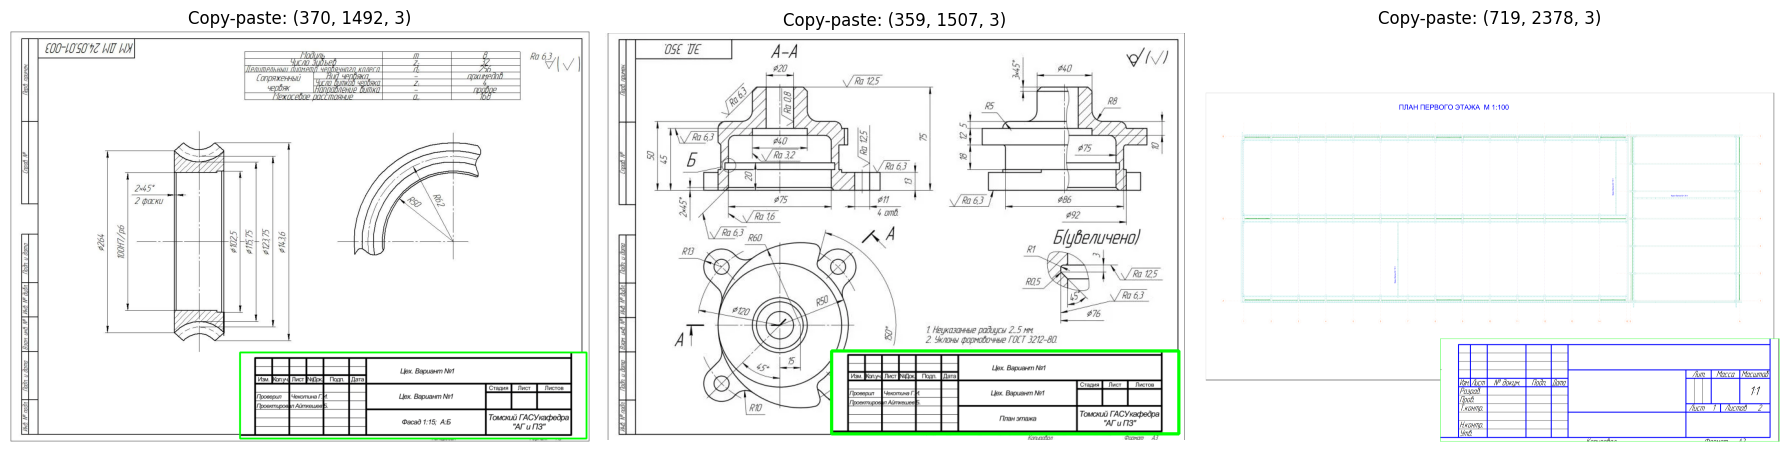

In [5]:
# Генерируем синтетику copy-paste
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
random.seed(42)
for i, ax in enumerate(axes):
    # Случайный штамп
    _, bg_img, stamp = real_stamps[i % len(real_stamps)]

    # Случайный фон
    _, bg2, _ = random.choice(real_stamps)

    synth, label, meta = generate_synthetic_from_real(bg2, stamp)
    x, y, w, h = meta['stamp_bbox']
    cv2.rectangle(synth, (x, y), (x+w, y+h), (0, 255, 0), 3)
    ax.imshow(cv2.cvtColor(synth, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Copy-paste: {stamp.shape}')
    ax.axis('off')

plt.tight_layout()
plt.show()


## Скрипт для генерации синтетических изображений
>  ⚠️ Запускать один раз

## v3 — Clean baseline: train_v3

Copy-paste использует 20 независимых фонов из `data/unlabeled/` (без утечки, как в v2).

**Изменения против v2:**
1. **Все 500 синтетических изображений идут в train** — убран 80/20 split на train/val.
2. **Валидация:** 10 реальных изображений из `data/images/val_honest/` (независимые штампы, стратифицированный выбор).
3. **Тест:** 35 реальных изображений (4 донора + 10 val_honest исключены).

Генерация в `data/images/train_v3/` и `data/labels/train_v3/`.


In [6]:
# Загружаем 20 немаркированных фонов из независимого источника
UNLABELED_DIR = DATA_DIR / "unlabeled"
clean_backgrounds = []
for p in sorted(UNLABELED_DIR.glob("*.jpg")) + sorted(UNLABELED_DIR.glob("*.png")):
    img = cv2.imread(str(p))
    if img is not None:
        clean_backgrounds.append(img)
print(f"Уникальных фонов: {len(clean_backgrounds)}")

# Загружаем 4 донорских штампа (из тестовых изображений)
DONORS = {"test_11.png", "test_17.png", "test_23.png", "test_42.png"}
donor_stamps = []
for fname in DONORS:
    img, labels = load_image_and_labels(
        DATA_DIR / "images" / "test" / fname,
        DATA_DIR / "labels" / "test"
    )
    stamp = crop_stamp_from_image(img, labels, margin=0.05)
    if stamp.size > 0:
        donor_stamps.append(stamp)
print(f"Донорских штампов: {len(donor_stamps)}")

Уникальных фонов: 20
Донорских штампов: 4


In [7]:
# Генерация GOST synthetic (250) в train_v4 (все на обучение, без 80/20 split)
TRAIN_DIR = DATA_DIR / "images" / "train_v4"
TRAIN_LBL_DIR = DATA_DIR / "labels" / "train_v4"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_LBL_DIR.mkdir(parents=True, exist_ok=True)

for i in range(50):
        if i % 50 == 0:
            print(f"GOST: {i}/50")
        img, label, _ = generate_synthetic_image(dpi=200)
        cv2.imwrite(str(TRAIN_DIR / f"gost_{i:04d}.png"), img)
        with open(TRAIN_LBL_DIR / f"gost_{i:04d}.txt", "w") as f:
            f.write(f"0 {label[1]:.6f} {label[2]:.6f} {label[3]:.6f} {label[4]:.6f}\n")
    print("GOST: done — 250 train")
else:
    print("GOST: already exists, skipping")

In [8]:
# Генерация Copy-paste (250) в train_v4 — фоны из data/unlabeled/ (без утечки)

for i in range(250):
        if i % 50 == 0:
            print(f"Copy-paste: {i}/250")
        bg = random.choice(clean_backgrounds)
        stamp = random.choice(donor_stamps)
        stamp = resize_stamp_for_bg(stamp, bg.shape[1], bg.shape[0])
        sh, sw = stamp.shape[:2]
        x, y = place_by_orientation(bg.shape[1], bg.shape[0], sw, sh)

        synth = bg.copy()
        synth[y:y+sh, x:x+sw] = stamp

        label = np.array([0, (x + sw / 2) / bg.shape[1], (y + sh / 2) / bg.shape[0], sw / bg.shape[1], sh / bg.shape[0]])

        cv2.imwrite(str(TRAIN_DIR / f"copy_{i:04d}.png"), synth)
        with open(TRAIN_LBL_DIR / f"copy_{i:04d}.txt", "w") as f:
            f.write(f"0 {label[1]:.6f} {label[2]:.6f} {label[3]:.6f} {label[4]:.6f}\n")
    print(f"Copy-paste: done — 250 train")
else:
    print("Copy-paste: already exists, skipping")

train_total = len(list(TRAIN_DIR.glob("*.png")))
print(f"train_v4: {train_total} images ({len(list(TRAIN_DIR.glob('gost_*.png')))} GOST + {len(list(TRAIN_DIR.glob('copy_*.png')))} copy-paste)")

In [ ]:
# v4: Генерация GOST-on-real-background (200) в train_v4 — штамп на реальном фоне
# Реальный фон уже содержит органический контент чертежа; synthetic doodles не добавляются.

if not list(TRAIN_DIR.glob("gost_bg_*.png")):
    for i in range(200):
        if i % 50 == 0:
            print(f"GOST-on-bg: {i}/200")
        bg = random.choice(clean_backgrounds)
        img, label, meta = generate_synthetic_image_on_background(bg, dpi=200)
        cv2.imwrite(str(TRAIN_DIR / f"gost_bg_{i:04d}.png"), img)
        with open(TRAIN_LBL_DIR / f"gost_bg_{i:04d}.txt", "w") as f:
            f.write(f"0 {label[1]:.6f} {label[2]:.6f} {label[3]:.6f} {label[4]:.6f}\n")
print("GOST-on-real-background done: 200 images")


In [9]:
# v4: Save generated data and val_honest to Google Drive (Colab only)
if IN_COLAB:
    from google.colab import drive
    DRIVE_PATH = "/content/drive/MyDrive/aie-group-2-data"
    drive.mount('/content/drive')
    import shutil
    for subdir in ["images", "labels"]:
        src = DATA_DIR / subdir
        dst = Path(DRIVE_PATH) / subdir
        if src.exists():
            dst.mkdir(parents=True, exist_ok=True)
            shutil.copytree(str(src), str(dst), dirs_exist_ok=True)
    # Also save val_honest (real validation set)
    for subdir in ["images", "labels"]:
        src = DATA_DIR / subdir / "val_honest"
        dst = Path(DRIVE_PATH) / subdir / "val_honest"
        if src.exists():
            dst.mkdir(parents=True, exist_ok=True)
            shutil.copytree(str(src), str(dst), dirs_exist_ok=True)
    # Also save config files
    for fname in ["gost_stamp.yaml", "donors.txt"]:
        fsrc = DATA_DIR / fname
        if fsrc.exists():
            shutil.copy2(str(fsrc), str(Path(DRIVE_PATH) / fname))
    print(f"Data saved to {DRIVE_PATH}")

Mounted at /content/drive
Data saved to /content/drive/MyDrive/aie-group-2-data


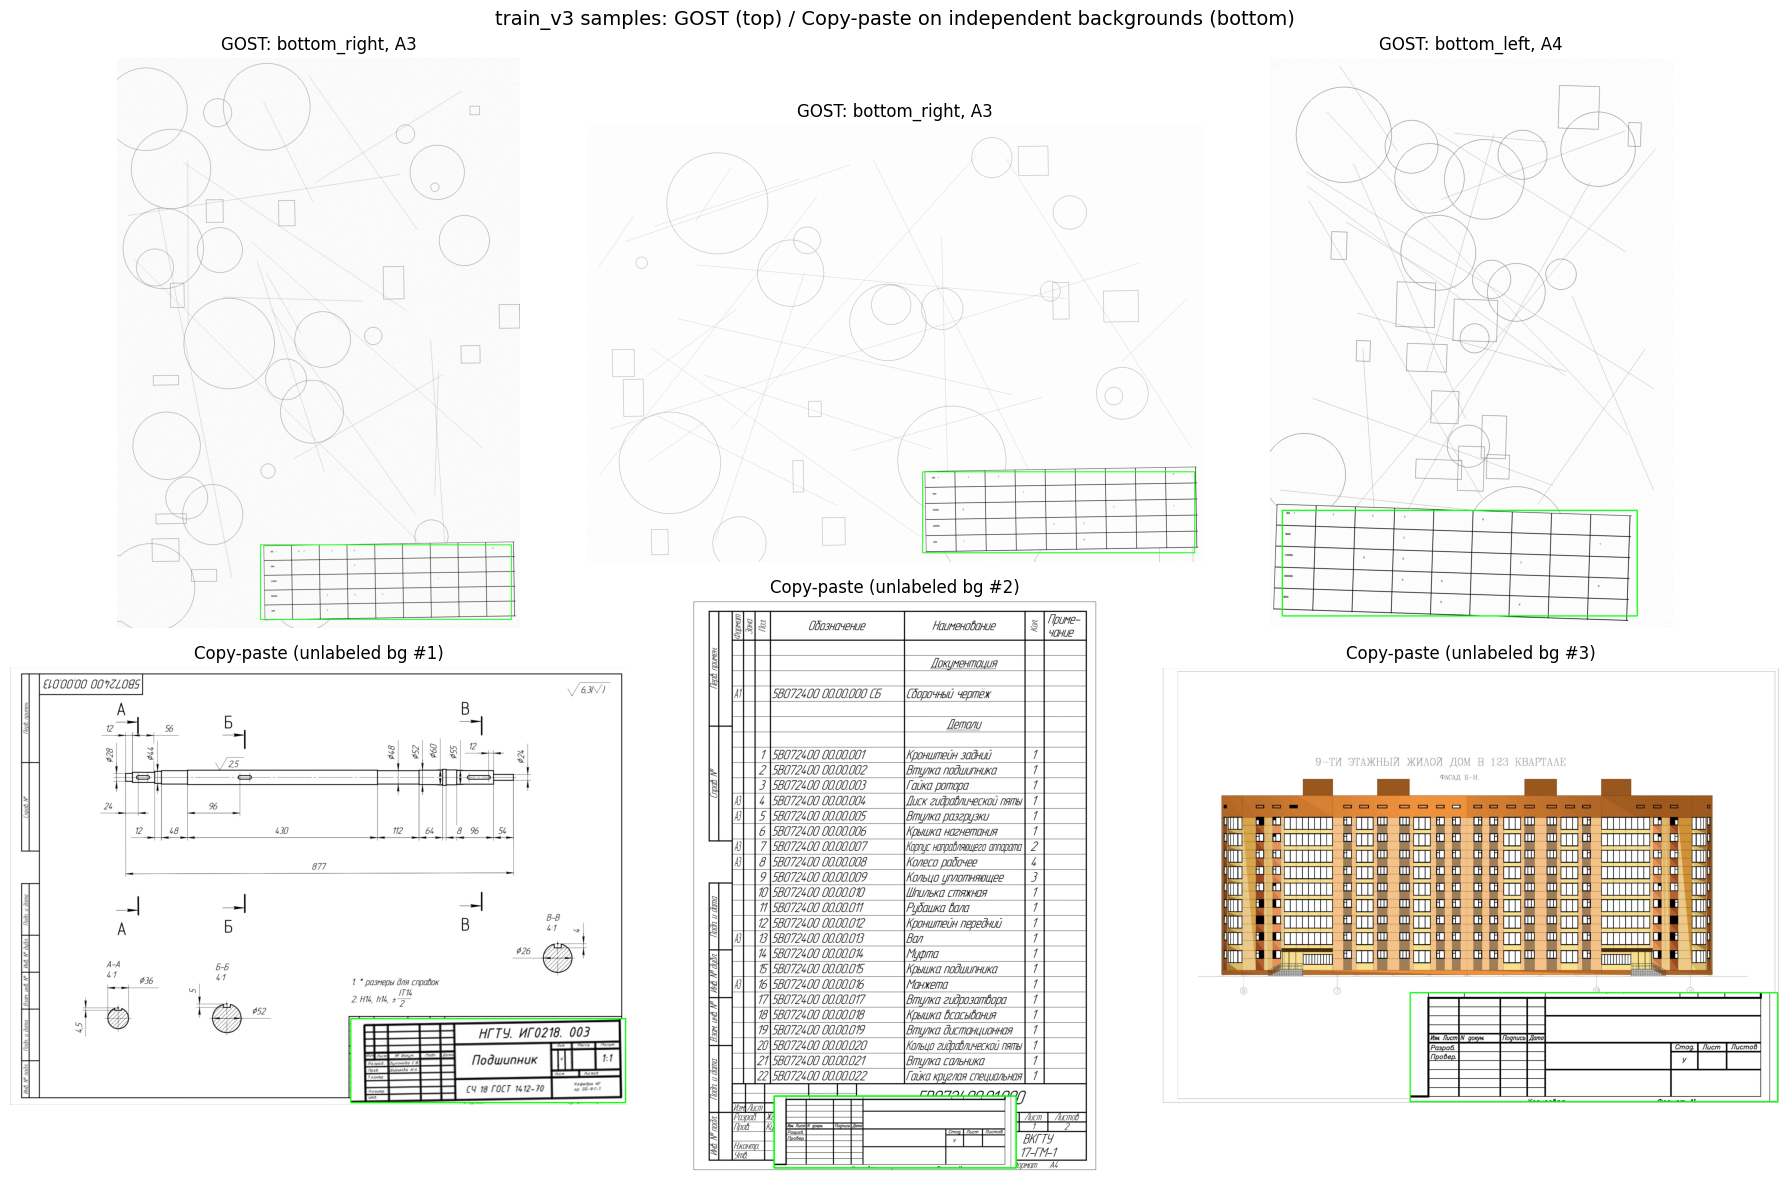

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# GOST samples (row 1)
for i, ax in enumerate(axes[0]):
    img, label, meta = generate_synthetic_image(dpi=200)
    x, y, w, h = meta['stamp_bbox']
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 3)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"GOST: {meta['corner']}, {meta['paper_size']}")
    ax.axis('off')

# Copy-paste samples (row 2) — inline, no GT leakage
random.seed(42)
for i, ax in enumerate(axes[1]):
    bg = random.choice(clean_backgrounds)
    stamp = random.choice(donor_stamps)
    scaled = resize_stamp_for_bg(stamp, bg.shape[1], bg.shape[0])
    sh, sw = scaled.shape[:2]
    x, y = place_by_orientation(bg.shape[1], bg.shape[0], sw, sh)

    synth = bg.copy()
    synth[y:y+sh, x:x+sw] = scaled
    cv2.rectangle(synth, (x, y), (x+sw, y+sh), (0, 255, 0), 3)

    ax.imshow(cv2.cvtColor(synth, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Copy-paste (unlabeled bg #{i+1})")
    ax.axis('off')

plt.suptitle("train_v3 samples: GOST (top) / Copy-paste on independent backgrounds (bottom)", fontsize=14)
plt.tight_layout()
plt.show()

## Итог

**train_v3** — 250 GOST + 250 copy-paste на 20 независимых фонах из `data/unlabeled/`.

- Все 500 изображений — в тренировку (без 80/20 split)
- Валидация: 10 реальных non-donor изображений (`val_honest/`)
- Тест: 35 реальных non-donor, non-val изображений
- `gost_stamp.yaml` уже указывает на `images/train_v3`

**Следующий шаг:** обучение YOLO / Faster R-CNN на train_v3.


## Выводы

**Доступные методы:**
1. **GOST генерация** — синтетический штамп с сеткой
2. **Copy-paste** — реальные штампы на случайных фонах

**Применение:**
- GOST: гарантированные размеры 185×55mm
- Copy-paste: более реалистичные штампы

**Следующий шаг:** Обучение YOLO
